In [ ]:
# Laden der Datensätze der Auswertung STT sowie Transkript (normal)
#
# 1 Gegenüberstellung Bewertung aus STT zu Transkript als Delta
# 1.1 Gruppieren nach Model und Delta, um zu analysieren, welche Auswirkung Fehler in der Spracherkennung im Ergebnis produzieren
# 1.2 Untersuchen, ob bei allen 3 Speakern ähnliche Fehler bei der Spracherkennung entstehen
# 1.3 Untersuchen, inwiefern sich Zusammenhänge zwischen Fehlertype bei der Spracherkennung und unterschiedlichen Bewertungen erkennen lassen
#
# 2 Filtern der 10 Datensätze, die 3 fach getestet wurden
# 2.1 Unterschied in Bewertung für gleiche Frage feststellen (Mittelwert und dann Delta)
# 2.2 Fehlercode mit erkanntem Mangel vergleichen

# 3.1 Delta in menschlicher Bewertung feststellen
# 3.2 Delta Bewertung Modelle zu Mittelwert der menschlichen Bewertung feststellen
# 3.3 Delta um Delta in menschlicher Bewertung korrigieren
# 3.3 Daten nach LLM und korrigiertem Delta gruppieren, Gegenüberstellung zu "normalem" Delta generieren

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Datensätze aus Evaluations-CSVs Speach-to-Text (stt) und PC-Eingabe (normal) einlesen
df_stt = pd.read_csv("llm_evaluation_combined_stt_with_error_type.csv")
df_normal = pd.read_csv("llm_evaluation_combined_normal.csv")

# unbeannte Spalten in df_normal, wenn nicht genutzt löschen, ansonsten beschriften
df_normal = df_normal.drop(columns=['Unnamed: 0.1'])
df_normal = df_normal.rename(columns={'Unnamed: 0':'id'})

# Zeile mit fehlendem Wert (Zeile 847) löschen
df_normal = df_normal.dropna(subset=["id"])

# Komma durch Punkt ersetzen in llm_rating
df_normal["llm_rating"] = df_normal["llm_rating"].str.replace(",", ".", regex=False)
df_stt["human_score"] = df_stt["human_score"].astype(str).str.split("/").str[0]
df_stt["llm_rating"] = df_stt["llm_rating"].str.replace(",", ".", regex=False)
df_stt["llm_rating"] = df_stt["llm_rating"].astype(str).str.split("/").str[0]

# Daten anhand der ersten 5 Einträge prüfen
df_normal.head()

,id,question,answer,llm_feedback,llm_rating,rueckfrage,student_answer,correct_answer,keywords,max_score,human_score,human_feedback,rueckfrage_human,model
0,152.0,Was ist der Zweck von t-Tests in der EDA?,"T-Tests in der EDA werden verwendet, um die Mi...",Die Antwort des Studenten ist im Wesentlichen ...,5.5,0.0,EDA steht für Explorative Datenanalyse. T-Test...,"T-Tests in der EDA werden verwendet, um die Mi...",t-Tests; unabhängige Stichproben; bekannter We...,6.0,6.0,1) Die Antwort wurde fachlich korrekt dargeste...,0.0,gemma3:27b
1,154.0,Was ist der Zweck nicht-parametrischer Tests i...,Nicht-parametrische Tests in der EDA werden ve...,Die Antwort des Studenten ist im Wesentlichen ...,3.5,1.0,Nicht-parametrische Tests in der EDA werden ve...,Nicht-parametrische Tests in der EDA werden ve...,nicht-parametrische Tests; EDA; Annahmen param...,4.0,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0.0,gemma3:27b
2,156.0,Was ist der Zweck der explorativen Faktorenana...,Die explorative Faktorenanalyse (EFA) im Rahme...,Die Antwort des Studenten ist im Wesentlichen ...,3.5,1.0,"Der Zweck besteht darin, die Ursache oder aber...",Die explorative Faktorenanalyse (EFA) im Rahme...,explorative Faktorenanalyse; EDA; zugrunde lie...,4.0,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0.0,gemma3:27b
3,157.0,Was ist der Unterschied zwischen EFA und Haupt...,EFA und PCA sind beide Verfahren zur Reduktion...,Die Antwort des Studenten ist leider nicht aus...,0.0,1.0,"Da ich nicht weiß, wofür EFA steht, kann ich l...",EFA und PCA sind beide Verfahren zur Reduktion...,EFA; PCA; Dimensionality Reduction; explorativ...,6.0,0.0,1) Die gegebene Antwort lässt keinen Rückschlu...,3.0,gemma3:27b
4,161.0,Was ist der Zweck eines Dendrogramms in der hi...,Ein Dendrogramm in der hierarchischen Clustera...,Die Antwort des Studenten ist grundsätzlich ko...,5.0,1.0,Ein Dendrogramm hilft in der hierarchischen Cl...,Ein Dendrogramm in der hierarchischen Clustera...,Dendrogramm; hierarchische Beziehungen; Mergin...,6.0,2.5,1) Die Antwort wurde fachlich korrekt dargeste...,2.0,gemma3:27b


In [30]:
# ID in df_normal zu integer konvertieren
df_normal["id"] = df_normal["id"].astype(int)

# llm_rating in df_normal zu float konvertieren
df_normal["llm_rating"] = df_normal["llm_rating"].astype(float)

# Prüfen bei welchen IDs in df_normal unterschiedliche Bewertungen vergeben wurden und Mittelwert aus vorhandenen Bewertungen bilden

rating_check = df_normal.groupby(["id", "model"])["llm_rating"].nunique()

dif_rating = rating_check[rating_check > 1]
count_dif = dif_rating.count()

# Textausgabe Anzahl der IDs mit unterschiedlichen Bewertungen
print(
    f"Bei {count_dif} IDs weicht der Wert des Ratings ab, für diese IDs wurde der Mittelwert verwendet"
)

# Mittelwert bilden und Spalte llm_rating umbenennen
df_normal_agg = (
    df_normal.groupby(["id", "model"], as_index=False)["llm_rating"]
    .mean()
    .rename(columns={"llm_rating": "llm_rating_normal"})
)

Bei 67 IDs weicht der Wert des Ratings ab, für diese IDs wurde der Mittelwert verwendet


In [31]:
# Join der Datensätze anhand id und model

df_merged = df_stt.merge(df_normal_agg, on=["id", "model"], how="inner")

df_merged["llm_rating"] = df_merged["llm_rating"].astype(str).str.split("/").str[0]

In [32]:
# Differenz zwischen stt_llm_rating und normal_llm_rating ermitteln für 1.1
df_merged["llm_rating"] = df_merged["llm_rating"].astype(float)

df_merged["llm_rating_delta"] = df_merged["llm_rating"] - df_merged["llm_rating_normal"]

In [33]:
# Delta auf ganzzahlig runden und gruppieren nach model und llm_rating_delta
df_merged["llm_rating_delta"] = df_merged["llm_rating_delta"].round()

# df_merged["llm_rating_delta"] = (df_merged["llm_rating_delta"]*2).round()/2

# Datensatz auf die 3 Spitzenmodelle filtern
df_merged_filtered = df_merged[
    df_merged["model"].isin(["gemma3:27b", "llama3.3:latest", "phi4:latest"])
]
grouped = (
    df_merged_filtered.groupby(["model", "llm_rating_delta"])
    .size()
    .reset_index(name="count")
)

# grouped = (df_merged.groupby(["model","llm_rating_delta"]).size().reset_index(name="count"))
grouped.head(20)

,model,llm_rating_delta,count
0,gemma3:27b,-1.0,13
1,gemma3:27b,-0.0,82
2,llama3.3:latest,-2.0,4
3,llama3.3:latest,-1.0,11
4,llama3.3:latest,-0.0,78
5,llama3.3:latest,1.0,2
6,phi4:latest,-2.0,5
7,phi4:latest,-1.0,15
8,phi4:latest,-0.0,67
9,phi4:latest,1.0,7


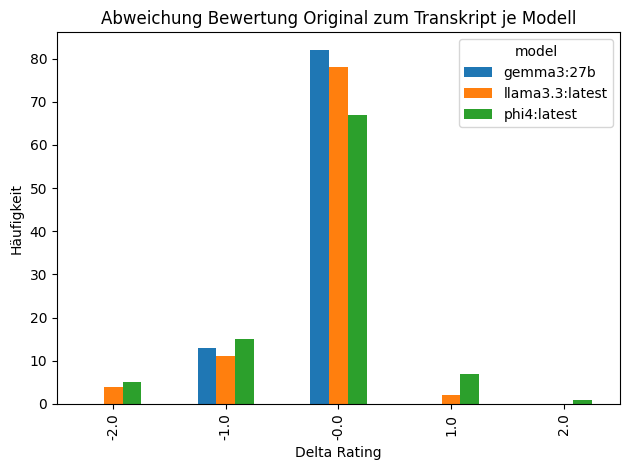

In [34]:
pivot_df = grouped.pivot(index="llm_rating_delta", columns="model", values="count")

pivot_df.plot(kind="bar")

plt.xlabel("Delta Rating")
plt.ylabel("Häufigkeit")
plt.title("Abweichung Bewertung Original zum Transkript je Modell")
plt.tight_layout()
plt.show()

In [40]:
#1.2 Untersuchen, ob bei allen 3 Speakern ähnliche Fehler bei der Spracherkennung entstehen

#Datentyp von llm_rating umwandeln in Float
df_stt["llm_rating"] = df_stt["llm_rating"].astype(float)

#Herausfiltern der 10 Datensätze, die von allen 3 Speakern getestet wurden
df_stt_evaluation = df_stt.groupby(["id","model"]).filter(lambda x: len(x) >1)

#Gruppieren nach Model und Abweichung in der llm-Bewertung unter Betrachtung der Abweichungen im Fehlercode
llm_delta = (df_stt_evaluation.groupby(["id","model"]).agg(
  llm_rat_min=("llm_rating", "min"),
  llm_rat_max=("llm_rating", "max"),
  error_min=("error_type", "min"),
  error_max=("error_type", "max")
  ))

llm_delta["rating_delta"]=llm_delta["llm_rat_max"]-llm_delta["llm_rat_min"]
llm_delta["error_delta"]=llm_delta["error_max"]-llm_delta["error_min"]

print(llm_delta)

                            llm_rat_min  llm_rat_max  error_min  error_max  \
id model                                                                     
3  command-r7b:latest               4.0          5.0        0.0        2.0   
   deepseek-r1:8b                   0.5          2.5        0.0        2.0   
   gemma3:27b                       3.0          4.0        0.0        2.0   
   gemma3:4b                        3.5          4.5        0.0        2.0   
   llama3.1:latest                  3.5          4.5        0.0        2.0   
...                                 ...          ...        ...        ...   
49 llama3.1:latest                  4.5          4.5        0.0        0.0   
   llama3.3:latest                  4.0          4.0        0.0        0.0   
   mistral-small3.1:latest          2.0          3.5        0.0        0.0   
   mixtral:latest                   2.0          5.0        0.0        0.0   
   phi4:latest                      2.5          4.5        0.0 

In [ ]:
#Durchschnittliche Abweichung im llm_rating pro Model über alle 10 Fragen der 3 Speaker hinweg

model_stats = (llm_delta.groupby("model").agg(
  avg_rating_delta = ("rating_delta","mean"),
))

print(model_stats)

                         avg_rating_delta
model                                    
command-r7b:latest                   0.93
deepseek-r1:8b                       1.50
gemma3:27b                           0.75
gemma3:4b                            0.85
llama3.1:latest                      0.50
llama3.3:latest                      0.75
mistral-small3.1:latest              1.55
mixtral:latest                       1.30
phi4:latest                          0.85


In [ ]:
# Herausfiltern von problematischen Fragen, bei denen kein Modell stabil bewertet bzw. bei denen der Fehlercode sich um mehr als eine Bewerungsstufe unterscheidet
# Instabilität in der Bewertung
ids_rating_problems = (llm_delta.groupby("id")["rating_delta"].min().loc[lambda x: x > 0].index)

print(ids_rating_problems)

#Instabilität in Bezug auf die Sprachliche Erkennung (Fehlercode)
ids_error_problems = llm_delta[llm_delta["error_delta"] > 1].index.get_level_values("id").unique()
print(ids_error_problems)

#Datensätze mit Problemen zur manuellen Betrachtung herausfiltern
problem_ids = set(ids_error_problems).union(set(ids_rating_problems))

problem_cases = (df_stt_evaluation[df_stt_evaluation["id"].isin(problem_ids)]
                 [["id","model","llm_rating","human_score","student_answer","error_type"]].sort_values(["id","model"]))

#Beispielhafte Betrachtung der Problemfälle mit Modell "phi4:latest"

problem_cases_phi = problem_cases[problem_cases["model"] == "phi4:latest"]

problem_cases_phi.head(30)

Index([3, 22, 42], dtype='int64', name='id')
Index([3, 35], dtype='int64', name='id')


,id,model,llm_rating,human_score,student_answer,error_type
15,3,phi4:latest,2.5,4.5,dieser trade off ist der Kompromiss zwischen d...,2.0
16,3,phi4:latest,3.5,4.0,Dieser Trade Off ist der Kompromiss zwischen d...,0.0
17,3,phi4:latest,2.5,2.0,Dieser Trade Off ist der Kompromiss zwischen d...,0.0
95,22,phi4:latest,5.5,6.0,Regularisierung in neuronalen Netzwerken beinh...,3.0
96,22,phi4:latest,6.0,6.0,Regularisierung in neuronalen Netzwerken beinh...,3.0
97,22,phi4:latest,4.5,6.0,Regularisierung in neuronalen Netzwerken beinh...,3.0
150,35,phi4:latest,0.0,1.0,puh da muss ich geschafft nachdenken Markus En...,3.0
151,35,phi4:latest,1.5,1.0,"Puh, da muss ich mal scharf nachdenken. Markov...",3.0
152,35,phi4:latest,1.5,2.5,"Puh, da muss ich scharf nachdenken. Markov Ent...",0.0
204,42,phi4:latest,5.5,6.0,da bin ich mir nicht so sicher aber ich glaube...,0.0
